In [1]:
import pandas as pd
import numpy as np
import re

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

# ── 1. DOSYALARI OKU ────────────────────────────────────────

try:
    df_train_raw = pd.read_csv('train.csv')
    df_test_raw  = pd.read_csv('test.csv')
    df_enriched  = pd.read_parquet('enriched.parquet')
except UnicodeDecodeError:
    df_train_raw = pd.read_csv('train.csv', encoding='latin-1')
    df_test_raw  = pd.read_csv('test.csv',  encoding='latin-1')

print(f"   train.csv    : {len(df_train_raw):,} satır, sütunlar: {list(df_train_raw.columns)}")
print(f"   test.csv     : {len(df_test_raw):,} satır,  sütunlar: {list(df_test_raw.columns)}")
print(f"   enriched     : {len(df_enriched):,} satır, sütunlar: {list(df_enriched.columns)}")


   train.csv    : 22,659 satır, sütunlar: ['Unnamed: 0', 'doi', 'abstract', 'title', 'category name', 'keywords', 'university', 'modded_Q_category', 'hf_prompt']
   test.csv     : 807 satır,  sütunlar: ['Unnamed: 0', 'doi', 'abstract', 'title', 'category name', 'keywords', 'university', 'modded_Q_category', 'hf_prompt']
   enriched     : 21,992 satır, sütunlar: ['doi', 'openalex_id', 'title', 'publication_year', 'publication_date', 'type', 'language', 'cited_by_count', 'counts_by_year', 'authors_count', 'authors', 'journal_name', 'journal_issn_l', 'publisher', 'is_oa', 'oa_status', 'topics', 'referenced_works_count', 'source']


In [2]:
# ── 2. DOI NORMALİZASYONU ───────────────────────────────────
def normalize_doi(doi):
    """
    Tüm DOI'leri küçük harfe çevirir ve bilinen prefix'leri temizler.
    Örn: 'https://doi.org/10.1002/ABC' → '10.1002/abc'
    """
    if pd.isna(doi):
        return None
    doi = str(doi).strip().lower()
    for prefix in ('https://doi.org/', 'http://doi.org/', 'doi.org/', 'doi:'):
        if doi.startswith(prefix):
            doi = doi[len(prefix):]
            break
    return doi if doi else None

df_train_raw['doi'] = df_train_raw['doi'].apply(normalize_doi)
df_test_raw['doi']  = df_test_raw['doi'].apply(normalize_doi)
df_enriched['doi']  = df_enriched['doi'].apply(normalize_doi)

# Normalizasyon öncesi/sonrası kontrolü (ilk 3 örnek)
print("   Örnek normalize edilmiş DOI (train):", df_train_raw['doi'].iloc[:3].tolist())


   Örnek normalize edilmiş DOI (train): ['10.1001/jama.2021.0507', '10.1001/jama.2023.18688', '10.1001/jamanetworkopen.2022.46901']


In [3]:

# ── 3. DUPLICATE DOI TEŞHİSİ ────────────────────────────────

dup_mask = df_train_raw.duplicated(subset=['doi'], keep=False)
n_dup_doi = df_train_raw[dup_mask]['doi'].nunique()
n_dup_rows = dup_mask.sum()

print(f"   Train'de birden fazla satırda görünen benzersiz DOI sayısı : {n_dup_doi:,}")
print(f"   Bu DOI'lere ait toplam satır sayısı                        : {n_dup_rows:,}")

if n_dup_doi > 0:
    # Neden tekrar var? Sütun bazında incele
    dup_examples = (
        df_train_raw[dup_mask]
        .groupby('doi')[['modded_Q_category', 'category name', 'university']]
        .agg(lambda x: list(x.unique()))
        .head(5)
    )
    print("\n   Örnek duplicate DOI'ler (farklı kategori/Q ataması var mı?):")
    print(dup_examples.to_string())

    # Q kategorisi farklı mı aynı mı?
    q_conflict = (
        df_train_raw[dup_mask]
        .groupby('doi')['modded_Q_category']
        .nunique()
        .gt(1)
        .sum()
    )
    print(f"\n   → Aynı DOI'de farklı Q kategorisi atanmış: {q_conflict:,} DOI")
    print(f"   → Aynı DOI'de aynı Q kategorisi (sadece kategori ismi farklı): {n_dup_doi - q_conflict:,} DOI")

    # Karar: Q çakışması yoksa keep='first' güvenli, varsa her satırı koru
    # Şimdi keep='first' ile temizliyoruz, bunu not ediyoruz
    df_train_raw = df_train_raw.drop_duplicates(subset=['doi'], keep='first')
    print(f"\n   Temizlik sonrası train satır sayısı: {len(df_train_raw):,}")

# Test'te duplicate var mı?
dup_test = df_test_raw.duplicated(subset=['doi']).sum()
print(f"\n   Test'te duplicate DOI: {dup_test}")


   Train'de birden fazla satırda görünen benzersiz DOI sayısı : 1,356
   Bu DOI'lere ait toplam satır sayısı                        : 2,712

   Örnek duplicate DOI'ler (farklı kategori/Q ataması var mı?):
                             modded_Q_category                           category name                          university
doi                                                                                                                       
10.1001/jama.2021.0507                    [Q1]          [MEDICINE, GENERAL & INTERNAL]               [Istanbul University]
10.1001/jamaneurol.2023.2815              [Q1]                    [CLINICAL NEUROLOGY]                [Kocaeli University]
10.1002/acp.3940                          [Q2]              [PSYCHOLOGY, EXPERIMENTAL]               [Boğaziçi University]
10.1002/adbi.202101317                    [Q3]       [MATERIALS SCIENCE, BIOMATERIALS]  [Middle East Technical University]
10.1002/adem.202201174                    [Q2]  [MATERIAL

In [4]:
# ── 4. MERGE ────────────────────────────────────────────────

df_train = pd.merge(df_train_raw, df_enriched, on='doi', how='left')
df_test  = pd.merge(df_test_raw,  df_enriched, on='doi', how='left')

# Satır sayısı korundu mu?
assert len(df_train) == len(df_train_raw), f"HATA: Train satır sayısı değişti! {len(df_train)} ≠ {len(df_train_raw)}"
assert len(df_test)  == len(df_test_raw),  f"HATA: Test satır sayısı değişti!  {len(df_test)} ≠ {len(df_test_raw)}"

# Merge kalitesi: enriched'dan kaç satır dolu geldi?
enriched_cols = ['cited_by_count', 'authors', 'publication_year']
print("\n   Merge sonrası kritik sütunların doluluğu:")
for col in enriched_cols:
    if col in df_train.columns:
        n_ok_train = df_train[col].notna().sum()
        n_ok_test  = df_test[col].notna().sum()
        print(f"   {col:25s} → train: {n_ok_train:,}/{len(df_train):,} ({100*n_ok_train/len(df_train):.1f}%)  "
              f"| test: {n_ok_test:,}/{len(df_test):,} ({100*n_ok_test/len(df_test):.1f}%)")

# Merge edilemeyen DOI'leri göster (enriched'de yoklar)
missing_train = df_train[df_train['authors'].isna()]['doi'].dropna().head(5).tolist()
print(f"\n   Enriched'da karşılığı olmayan örnek DOI'ler (train): {missing_train}")

# Merge sütun ismi çakışması var mı? (_x, _y eki)
conflict_cols = [c for c in df_train.columns if c.endswith('_x') or c.endswith('_y')]
if conflict_cols:
    print(f"\n   Çakışan sütunlar (merge sonrası _x/_y eki aldı): {conflict_cols}")

    # title: enriched'daki title_y'yi at, orijinal title_x'i koru (daha temiz kaynak)
    for col in conflict_cols:
        base = col[:-2]  # '_x' veya '_y' çıkar
        if col.endswith('_x') and f"{base}_y" in df_train.columns:
            df_train = df_train.rename(columns={col: base}).drop(columns=[f"{base}_y"], errors='ignore')
            df_test  = df_test.rename(columns={col: base}).drop(columns=[f"{base}_y"], errors='ignore')
            print(f"   → '{base}_x' → '{base}' olarak yeniden adlandırıldı, '{base}_y' silindi.")



   Merge sonrası kritik sütunların doluluğu:
   cited_by_count            → train: 21,162/21,303 (99.3%)  | test: 802/807 (99.4%)
   authors                   → train: 21,190/21,303 (99.5%)  | test: 802/807 (99.4%)
   publication_year          → train: 21,190/21,303 (99.5%)  | test: 802/807 (99.4%)

   Enriched'da karşılığı olmayan örnek DOI'ler (train): ['10.1002/pmic.202300282', '10.1002/pmrj.12542', '10.1002/poc.4453', '10.1007/jhep01(2022)010', '10.12989/amr.2021.10.3.229']

   Çakışan sütunlar (merge sonrası _x/_y eki aldı): ['title_x', 'title_y']
   → 'title_x' → 'title' olarak yeniden adlandırıldı, 'title_y' silindi.


In [5]:

# ── 5. KAYDET ────────────────────────────────────────────────
df_train.to_parquet('train_full.parquet', index=False)
df_test.to_parquet('test_full.parquet',   index=False)

print(f"    train_full.parquet : {df_train.shape}  (satır × sütun)")
print(f"    test_full.parquet  : {df_test.shape}")
print(f"\n   Final sütunlar: {list(df_train.columns)}")
print("\n ADIM 2 TAMAMLANDI")

    train_full.parquet : (21303, 26)  (satır × sütun)
    test_full.parquet  : (807, 26)

   Final sütunlar: ['Unnamed: 0', 'doi', 'abstract', 'title', 'category name', 'keywords', 'university', 'modded_Q_category', 'hf_prompt', 'openalex_id', 'publication_year', 'publication_date', 'type', 'language', 'cited_by_count', 'counts_by_year', 'authors_count', 'authors', 'journal_name', 'journal_issn_l', 'publisher', 'is_oa', 'oa_status', 'topics', 'referenced_works_count', 'source']

 ADIM 2 TAMAMLANDI


In [7]:
# ============================================================
# ADIM 2b: VERİ KALİTESİ RAPORU
# ============================================================
import pandas as pd
import numpy as np
import json

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

df_train = pd.read_parquet('train_full.parquet')
df_test  = pd.read_parquet('test_full.parquet')

print("=" * 65)
print(" BÖLÜM 1: GENEL SÜTUN DOLULUK RAPORU")
print("=" * 65)

def doluluk_raporu(df, name):
    toplam = len(df)
    rows = []
    for col in df.columns:
        eksik = df[col].isna().sum()
        dolu  = toplam - eksik
        rows.append({
            'Sütun'       : col,
            'Dolu'        : dolu,
            'Eksik'       : eksik,
            'Doluluk (%)'  : round(100 * dolu / toplam, 1)
        })
    rapor = pd.DataFrame(rows)
    print(f"\n{name} ({toplam:,} satır):")
    print(rapor.to_string(index=False))
    return rapor

rapor_train = doluluk_raporu(df_train, "TRAIN")
rapor_test  = doluluk_raporu(df_test,  "TEST")


# ── Crossref kaynaklı satırlarda neden cited_by_count null? ─
print("\n" + "=" * 65)
print(" BÖLÜM 2: CROSSREF vs OPENALEX BREAKDOWN")
print("=" * 65)
print("\nTrain kaynak dağılımı:")
print(df_train['source'].value_counts(dropna=False))
crossref_mask = df_train['source'] == 'crossref'
print(f"\nCrossref'ten gelen satır sayısı: {crossref_mask.sum()}")
if crossref_mask.sum() > 0:
    cr_null_cite = df_train.loc[crossref_mask, 'cited_by_count'].isna().sum()
    print(f"   Bu satırlarda cited_by_count null: {cr_null_cite} "
          f"({100*cr_null_cite/crossref_mask.sum():.0f}%)")
    
# Hiç source'u olmayanlar (enriched'da hiç bulunamayanlar)
no_source = df_train['source'].isna().sum()
print(f"\nHiçbir kaynakta bulunamayan (source=NaN): {no_source} satır")


# ── Dil dağılımı ────────────────────────────────────────────
print("\n" + "=" * 65)
print(" BÖLÜM 3: DİL DAĞILIMI VE TÜRKÇE ABSTRACT ANALİZİ")
print("=" * 65)

print("\nTrain dil dağılımı (language sütunu):")
print(df_train['language'].value_counts(dropna=False).head(10))

# language=NaN olanlar: enriched'da bulunamayan + crossref kaynaklı
lang_null = df_train['language'].isna().sum()
print(f"\nDil bilgisi null: {lang_null} (enriched'da bulunamayan makaleler)")

# Abstract metnini kullanarak gerçek Türkçe içerik oranını kontrol edelim
# (OpenAlex 'tr' dese de abstract İngilizce olabilir veya tam tersi)
import re

def dili_tespit_et(text):
    """
    Basit sezgisel: Türkçe'ye özgü karakterler içeriyorsa 'tr', yoksa 'en' tahmin eder.
    OpenAlex'in 'language' sütununun ne kadar güvenilir olduğunu çapraz kontrol eder.
    """
    if pd.isna(text) or len(str(text).strip()) == 0:
        return 'empty'
    turkce_chars = set('ğüşıöçĞÜŞİÖÇ')
    if any(c in str(text) for c in turkce_chars):
        return 'tr_detected'
    return 'en_detected'

df_train['lang_detected'] = df_train['abstract'].apply(dili_tespit_et)

print("\nAbstract içeriğinden tespit edilen dil (karakter bazlı):")
print(df_train['lang_detected'].value_counts())

# OpenAlex 'tr' deyip abstract'ı İngilizce olan var mı?
oa_tr = df_train['language'] == 'tr'
detected_tr = df_train['lang_detected'] == 'tr_detected'

print(f"\nOpenAlex 'tr' etiketli: {oa_tr.sum()}")
print(f"Türkçe karakter içeren abstract: {detected_tr.sum()}")
print(f"OpenAlex 'tr' ama Türkçe karakter YOK (muhtemelen İngilizce abstract): "
      f"{(oa_tr & ~detected_tr).sum()}")
print(f"OpenAlex 'tr' VE Türkçe karakter VAR (gerçekten Türkçe): "
      f"{(oa_tr & detected_tr).sum()}")
print(f"OpenAlex 'en' ama Türkçe karakter İÇERİYOR (karışık/yanlış etiket): "
      f"{((df_train['language'] == 'en') & detected_tr).sum()}")



# ── Outlier analizi ─────────────────────────────────────────
print("\n" + "=" * 65)
print(" BÖLÜM 4: OUTLIER ANALİZİ")
print("=" * 65)

# Sayısal sütunlar
num_cols = ['cited_by_count', 'authors_count', 'referenced_works_count', 'publication_year']
available = [c for c in num_cols if c in df_train.columns]

stats = df_train[available].describe(percentiles=[.25, .5, .75, .90, .95, .99]).round(1)
print(stats.T.to_string())

# authors_count outlier analizi (eski notebook'ta max=4870 idi)
print("\n--- authors_count dağılım katmanları ---")
thresholds = [10, 20, 50, 100, 200, 500]
for t in thresholds:
    n = (df_train['authors_count'] > t).sum()
    pct = 100 * n / len(df_train)
    print(f"  authors_count > {t:4d}: {n:5,} makale ({pct:.1f}%)")

# Dev makalelerin Q dağılımı
print("\nauthor_count > 50 olan makalelerin Q dağılımı:")
big_collab = df_train[df_train['authors_count'] > 50]
print(big_collab['modded_Q_category'].value_counts())
print(f"Bu makalelerin ortalama atıfı: {big_collab['cited_by_count'].mean():.1f}")
print(f"Normal makalelerin ortalama atıfı: {df_train[df_train['authors_count'] <= 50]['cited_by_count'].mean():.1f}")

# cited_by_count outlier
print("\n--- cited_by_count aşırı uç değerleri ---")
q99 = df_train['cited_by_count'].quantile(0.99)
extreme = df_train[df_train['cited_by_count'] > q99]
print(f"  %99 yüzdelik dilim: {q99:.0f} atıf")
print(f"  Bunun üstünde: {len(extreme):,} makale ({100*len(extreme)/len(df_train):.1f}%)")
print(f"  En yüksek 5 atıf: {sorted(df_train['cited_by_count'].dropna(), reverse=True)[:5]}")

# Makale yaşı
print("\n--- Yayın yılı dağılımı ---")
print(df_train['publication_year'].value_counts().sort_index())

print("\n ADIM 2b TAMAMLANDI")

 BÖLÜM 1: GENEL SÜTUN DOLULUK RAPORU

TRAIN (21,303 satır):
                 Sütun  Dolu  Eksik  Doluluk (%)
            Unnamed: 0 21303      0        100.0
                   doi 21303      0        100.0
              abstract 21303      0        100.0
                 title 21303      0        100.0
         category name 21303      0        100.0
              keywords 18074   3229         84.8
            university 21303      0        100.0
     modded_Q_category 21303      0        100.0
             hf_prompt 21303      0        100.0
           openalex_id 21162    141         99.3
      publication_year 21190    113         99.5
      publication_date 21162    141         99.3
                  type 21190    113         99.5
              language 21173    130         99.4
        cited_by_count 21162    141         99.3
        counts_by_year 21162    141         99.3
         authors_count 21190    113         99.5
               authors 21190    113         99.5
         

In [8]:
# ADIM 2c: KEŞİFSEL VERİ ANALİZİ (EDA)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 120)

df_train = pd.read_parquet('train_full.parquet')

# ── Yardımcı: authors JSON parse ────────────────────────────
def parse_authors(raw):
    """
    authors sütununu güvenle parse eder.
    Liste/ndarray ise doğrudan kullanır, string ise json.loads dener.
    Hata durumunda boş liste döner.
    """
    if raw is None or (isinstance(raw, float) and np.isnan(raw)):
        return []
    if isinstance(raw, (list, np.ndarray)):
        return [a.get('name', '') for a in raw if isinstance(a, dict) and a.get('name')]
    if isinstance(raw, str) and raw.strip().startswith('['):
        try:
            parsed = json.loads(raw)
            return [a.get('name', '') for a in parsed if isinstance(a, dict) and a.get('name')]
        except Exception:
            pass
    return []

def parse_counts_by_year(raw):
    """counts_by_year sütununu liste of dict'e çevirir."""
    if raw is None or (isinstance(raw, float) and np.isnan(raw)):
        return []
    if isinstance(raw, list):
        return raw
    if isinstance(raw, str) and raw.strip().startswith('['):
        try:
            return json.loads(raw)
        except Exception:
            pass
    return []

# Ön hesaplamalar
df_train['abstract_len']    = df_train['abstract'].astype(str).apply(len)
df_train['clean_authors']   = df_train['authors'].apply(parse_authors)
df_train['author_count_real'] = df_train['clean_authors'].apply(len)
df_train['article_age']     = 2024 - df_train['publication_year'].fillna(2022)
df_train['is_large_collab'] = df_train['authors_count'] > 50  # flag, silmiyoruz

# Q sayısal (korelasyon için)
q_map = {'Q1': 4, 'Q2': 3, 'Q3': 2, 'Q4': 1}
df_train['Q_numeric'] = df_train['modded_Q_category'].map(q_map)


print("=" * 65)
print(" BÖLÜM 1: KALİTE MODELİ EDA (Q KATEGORİSİ)")
print("=" * 65)

# ── Q bazında sayısal özet ───────────────────────────────────
normal = df_train[~df_train['is_large_collab']]   # 50+ yazar hariç
big    = df_train[df_train['is_large_collab']]

print(f"\nQ kategorisi dağılımı (tüm veri):")
q_dist = df_train['modded_Q_category'].value_counts()
for q, n in q_dist.items():
    print(f"  {q}: {n:,}  ({100*n/len(df_train):.1f}%)")

print(f"\nNormal makaleler (authors_count ≤ 50): {len(normal):,}")
print(f"Büyük işbirliği  (authors_count > 50): {len(big):,}")

print("\n── Q bazında ortalama değerler (normal makaleler) ──")
q_stats = normal.groupby('modded_Q_category').agg(
    ortalama_atif    = ('cited_by_count', 'mean'),
    medyan_atif      = ('cited_by_count', 'median'),
    ort_yazar        = ('authors_count',  'mean'),
    ort_abstract_len = ('abstract_len',   'mean'),
    ort_referans     = ('referenced_works_count', 'mean'),
    oa_orani         = ('is_oa',          'mean'),
    n                = ('doi',            'count')
).round(2).reindex(['Q1','Q2','Q3','Q4'])
print(q_stats.to_string())

# ── Korelasyon tablosu ───────────────────────────────────────
print("\n── Q_numeric ile sayısal özelliklerin korelasyonu ──")
corr_cols = ['Q_numeric', 'cited_by_count', 'referenced_works_count',
             'authors_count', 'abstract_len', 'article_age']
corr_cols = [c for c in corr_cols if c in df_train.columns]
corr = normal[corr_cols].corr()['Q_numeric'].sort_values(ascending=False)
for feat, val in corr.items():
    bar = '█' * int(abs(val) * 30)
    sign = '+' if val >= 0 else '-'
    print(f"  {feat:30s}: {val:+.4f}  {sign}{bar}")


 BÖLÜM 1: KALİTE MODELİ EDA (Q KATEGORİSİ)

Q kategorisi dağılımı (tüm veri):
  Q4: 5,560  (26.1%)
  Q2: 5,552  (26.1%)
  Q1: 5,365  (25.2%)
  Q3: 4,826  (22.7%)

Normal makaleler (authors_count ≤ 50): 20,644
Büyük işbirliği  (authors_count > 50): 659

── Q bazında ortalama değerler (normal makaleler) ──
                   ortalama_atif  medyan_atif  ort_yazar  ort_abstract_len  ort_referans  oa_orani     n
modded_Q_category                                                                                       
Q1                         25.19         11.0       7.10           1515.38         51.82  0.675311  4921
Q2                         15.45          9.0       5.64           1380.68         47.95  0.578122  5389
Q3                          9.17          5.0       4.75           1377.50         38.67  0.516555  4813
Q4                          4.65          3.0       4.34           1367.97         29.40  0.674877  5521

── Q_numeric ile sayısal özelliklerin korelasyonu ──
  Q_numeri

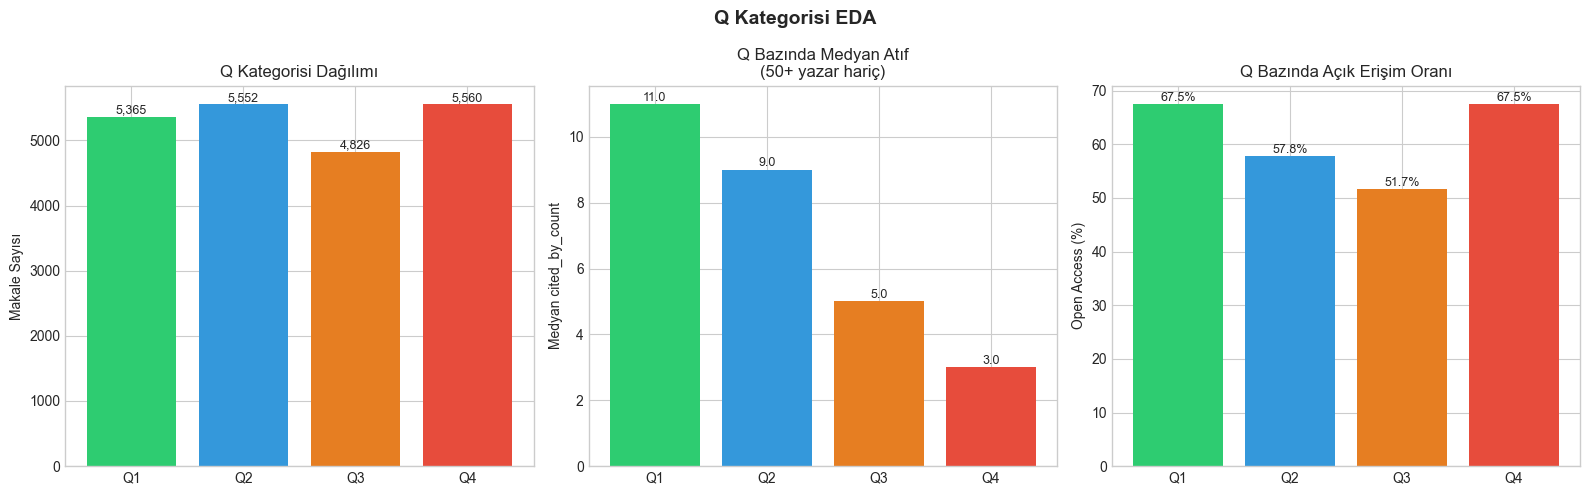

    eda_q_kategori.png kaydedildi


In [9]:

# ── Görselleştirme 1: Q bazında atıf dağılımı ───────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Q Kategorisi EDA', fontsize=14, fontweight='bold')

# Grafik 1a: Q dağılımı
q_counts = df_train['modded_Q_category'].value_counts().reindex(['Q1','Q2','Q3','Q4'])
axes[0].bar(q_counts.index, q_counts.values,
            color=['#2ecc71','#3498db','#e67e22','#e74c3c'])
axes[0].set_title('Q Kategorisi Dağılımı')
axes[0].set_ylabel('Makale Sayısı')
for i, (idx, val) in enumerate(q_counts.items()):
    axes[0].text(i, val + 50, f'{val:,}', ha='center', fontsize=9)

# Grafik 1b: Q bazında medyan atıf (normal makaleler)
q_med = normal.groupby('modded_Q_category')['cited_by_count'].median().reindex(['Q1','Q2','Q3','Q4'])
axes[1].bar(q_med.index, q_med.values,
            color=['#2ecc71','#3498db','#e67e22','#e74c3c'])
axes[1].set_title('Q Bazında Medyan Atıf\n(50+ yazar hariç)')
axes[1].set_ylabel('Medyan cited_by_count')
for i, (idx, val) in enumerate(q_med.items()):
    axes[1].text(i, val + 0.1, f'{val:.1f}', ha='center', fontsize=9)

# Grafik 1c: Q bazında OA oranı
q_oa = normal.groupby('modded_Q_category')['is_oa'].mean().reindex(['Q1','Q2','Q3','Q4'])
axes[2].bar(q_oa.index, q_oa.values * 100,
            color=['#2ecc71','#3498db','#e67e22','#e74c3c'])
axes[2].set_title('Q Bazında Açık Erişim Oranı')
axes[2].set_ylabel('Open Access (%)')
for i, (idx, val) in enumerate(q_oa.items()):
    axes[2].text(i, val * 100 + 0.5, f'{val*100:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_q_kategori.png', dpi=150, bbox_inches='tight')
plt.show()
print("    eda_q_kategori.png kaydedildi")


In [10]:

print("\n" + "=" * 65)
print(" BÖLÜM 2: ATIF TAHMİNİ EDA (counts_by_year)")
print("=" * 65)

# counts_by_year parse
df_train['cby_parsed'] = df_train['counts_by_year'].apply(parse_counts_by_year)
df_train['cby_length'] = df_train['cby_parsed'].apply(len)

print(f"\ncounts_by_year kaç yıllık veri içeriyor (dolu satırlar):")
cby_len_dist = df_train[df_train['cby_length'] > 0]['cby_length'].value_counts().sort_index()
for yil, n in cby_len_dist.items():
    bar = '█' * int(n / 100)
    print(f"  {yil:2d} yıl: {n:5,}  {bar}")

# Makale yaşı vs toplam atıf (normal makaleler, 0 atıflılar dahil)
print("\n── Makale yaşına göre atıf özeti (normal makaleler) ──")
age_stats = (
    normal.groupby('article_age')['cited_by_count']
    .agg(['mean', 'median', 'count'])
    .round(2)
    .rename(columns={'mean':'Ort_Atıf', 'median':'Med_Atıf', 'count':'N'})
)
print(age_stats.to_string())

# counts_by_year'dan yıllık atıf eğrisi (örnek: 2020 makaleleri)
print("\n── 2020 yılı makalelerinin yıl-yıl atıf eğrisi ──")
df_2020 = df_train[(df_train['publication_year'] == 2020) & (df_train['cby_length'] > 0)]
yearly_agg = {}
for _, row in df_2020.iterrows():
    for entry in row['cby_parsed']:
        y = entry.get('year')
        c = entry.get('cited_by_count', 0)
        if y and y >= 2020:
            yearly_agg[y] = yearly_agg.get(y, []) + [c]

if yearly_agg:
    for y in sorted(yearly_agg.keys()):
        vals = yearly_agg[y]
        print(f"  {y}: ort={np.mean(vals):.1f}  med={np.median(vals):.1f}  n={len(vals)}")



 BÖLÜM 2: ATIF TAHMİNİ EDA (counts_by_year)

counts_by_year kaç yıllık veri içeriyor (dolu satırlar):
   1 yıl: 2,786  ███████████████████████████
   2 yıl: 3,443  ██████████████████████████████████
   3 yıl: 4,020  ████████████████████████████████████████
   4 yıl: 4,175  █████████████████████████████████████████
   5 yıl: 2,776  ███████████████████████████
   6 yıl: 1,406  ██████████████
   7 yıl:   252  ██
   8 yıl:    31  
   9 yıl:     2  
  10 yıl:     1  
  12 yıl:     1  
  15 yıl:     1  

── Makale yaşına göre atıf özeti (normal makaleler) ──
             Ort_Atıf  Med_Atıf     N
article_age                          
0.0              2.41       0.0    34
1.0              9.51       4.0  5878
2.0             12.23       5.0  6191
3.0             16.25       7.0  6467
4.0             20.18      10.0  1748
5.0             18.35      10.0   162
6.0             15.94      10.5    16
7.0              6.00       2.0     4
8.0              1.00       1.0     4
9.0              1.67 

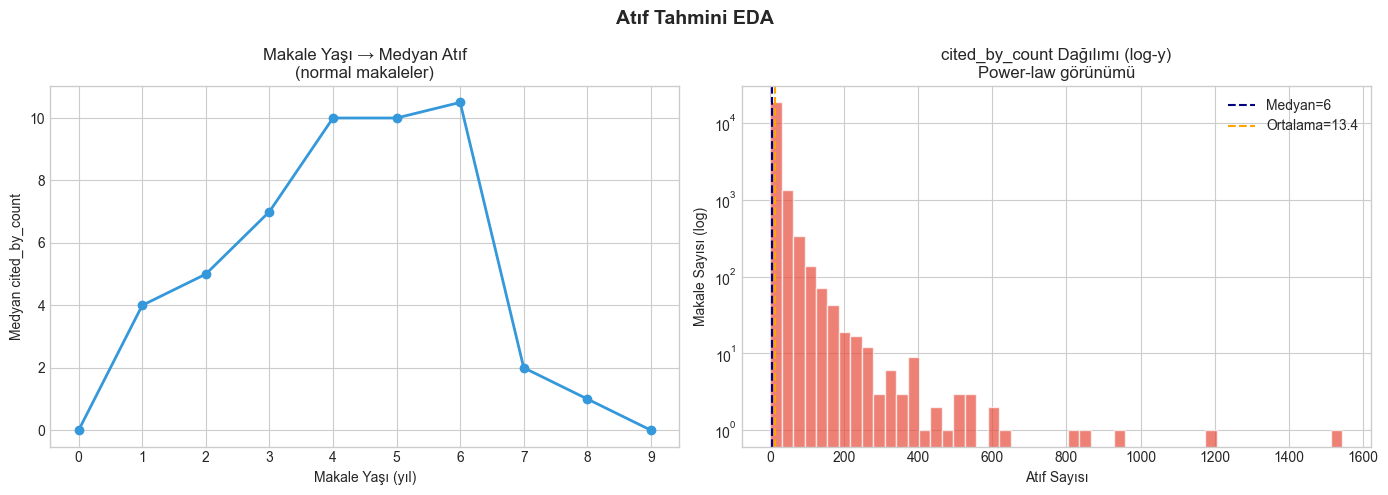

    eda_atif.png kaydedildi


In [11]:

# Görselleştirme 2: Makale yaşı vs atıf
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Atıf Tahmini EDA', fontsize=14, fontweight='bold')

age_med = normal.groupby('article_age')['cited_by_count'].median()
axes[0].plot(age_med.index, age_med.values, marker='o', linewidth=2, color='#3498db')
axes[0].set_title('Makale Yaşı → Medyan Atıf\n(normal makaleler)')
axes[0].set_xlabel('Makale Yaşı (yıl)')
axes[0].set_ylabel('Medyan cited_by_count')
axes[0].set_xticks(sorted(age_med.index))

# cited_by_count histogram (log-scale)
cite_vals = normal['cited_by_count'].dropna()
axes[1].hist(cite_vals, bins=50, color='#e74c3c', alpha=0.7, edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('cited_by_count Dağılımı (log-y)\nPower-law görünümü')
axes[1].set_xlabel('Atıf Sayısı')
axes[1].set_ylabel('Makale Sayısı (log)')
axes[1].axvline(cite_vals.median(), color='navy', linestyle='--',
                label=f'Medyan={cite_vals.median():.0f}')
axes[1].axvline(cite_vals.mean(), color='orange', linestyle='--',
                label=f'Ortalama={cite_vals.mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_atif.png', dpi=150, bbox_inches='tight')
plt.show()
print("    eda_atif.png kaydedildi")


In [12]:

print("\n" + "=" * 65)
print(" BÖLÜM 3: İŞBİRLİĞİ TAHMİNİ EDA (YAZAR AĞI)")
print("=" * 65)

# Sadece normal makaleleri (authors_count ≤ 50) kullan
# Büyük işbirlikleri ağ istatistiklerini tahrip ediyor
df_net = df_train[~df_train['is_large_collab']].copy()
df_net_authors = df_net['clean_authors'].apply(
    lambda x: x if isinstance(x, list) else []
)

# Temel ağ istatistikleri
all_author_mentions = [a for lst in df_net_authors for a in lst]
unique_authors      = set(all_author_mentions)

from collections import Counter
author_freq = Counter(all_author_mentions)

print(f"\nNormal makaleler (authors_count ≤ 50): {len(df_net):,}")
print(f"Toplam yazar mention : {len(all_author_mentions):,}")
print(f"Benzersiz yazar sayısı (düğüm): {len(unique_authors):,}")
print(f"Yazar başına ort. makale: {len(all_author_mentions)/max(len(unique_authors),1):.2f}")

print("\n── Yazar makale sayısı dağılımı ──")
freq_dist = Counter(author_freq.values())
for n_papers in sorted(freq_dist.keys())[:8]:
    n_authors = freq_dist[n_papers]
    bar = '█' * min(int(n_authors / 200), 40)
    print(f"  {n_papers:2d} makale → {n_authors:6,} yazar  {bar}")
print(f"  ...")
print(f"  5+ makale → {sum(v for k,v in freq_dist.items() if k >= 5):,} yazar")
print(f"  10+ makale → {sum(v for k,v in freq_dist.items() if k >= 10):,} yazar")

print("\n── En üretken 10 yazar ──")
for author, count in author_freq.most_common(10):
    print(f"  {author}: {count} makale")

# Zaman eksenli bölünme testi
df_past   = df_net[df_net['publication_year'] <= 2022]
df_future = df_net[df_net['publication_year'] > 2022]
print(f"\n── Temporal split (link prediction için) ──")
print(f"  2022 ve öncesi (geçmiş ağ) : {len(df_past):,} makale")
print(f"  2023 ve sonrası (gelecek ağ): {len(df_future):,} makale")

past_authors = set(a for lst in df_past['clean_authors'] for a in lst)
fut_authors  = set(a for lst in df_future['clean_authors'] for a in lst)
overlap = past_authors & fut_authors
print(f"  Geçmiş ağdaki yazar sayısı  : {len(past_authors):,}")
print(f"  Gelecek ağdaki yazar sayısı : {len(fut_authors):,}")
print(f"  İkisinde de görünen yazar   : {len(overlap):,} ({100*len(overlap)/max(len(fut_authors),1):.1f}%)")

# Üniversite bazında işbirliği yoğunluğu
print("\n── Üniversite bazında ortalama yazar sayısı ──")
univ_avg = df_net.groupby('university')['author_count_real'].mean().sort_values(ascending=False)
for univ, avg in univ_avg.items():
    print(f"  {univ:40s}: {avg:.2f}")



 BÖLÜM 3: İŞBİRLİĞİ TAHMİNİ EDA (YAZAR AĞI)

Normal makaleler (authors_count ≤ 50): 20,644
Toplam yazar mention : 111,589
Benzersiz yazar sayısı (düğüm): 60,507
Yazar başına ort. makale: 1.84

── Yazar makale sayısı dağılımı ──
   1 makale → 42,699 yazar  ████████████████████████████████████████
   2 makale →  8,767 yazar  ████████████████████████████████████████
   3 makale →  3,550 yazar  █████████████████
   4 makale →  1,806 yazar  █████████
   5 makale →    998 yazar  ████
   6 makale →    686 yazar  ███
   7 makale →    444 yazar  ██
   8 makale →    344 yazar  █
  ...
  5+ makale → 3,685 yazar
  10+ makale → 971 yazar

── En üretken 10 yazar ──
  Dumitru Bǎleanu: 284 makale
  Fahd Jarad: 133 makale
  Sezai Erċışlı: 125 makale
  Levent Özçakar: 85 makale
  İlhami Gülçın: 81 makale
  Seza Özen: 79 makale
  Ömer Karadağ: 68 makale
  Umut Kalyoncu: 67 makale
  A.M. Abd El‐Aty: 62 makale
  Metin Sitti: 60 makale

── Temporal split (link prediction için) ──
  2022 ve öncesi (geçmiş a

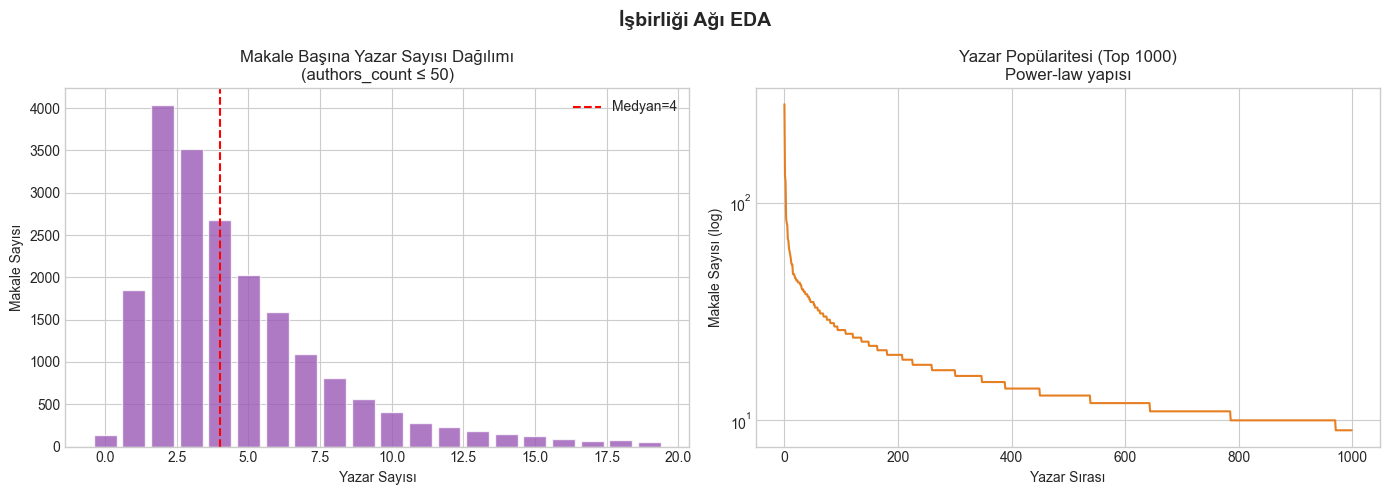

    eda_isbirligi.png kaydedildi

 ADIM 2c TAMAMLANDI


In [13]:

# Görselleştirme 3: Yazar dağılımı
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('İşbirliği Ağı EDA', fontsize=14, fontweight='bold')

# Makale başına yazar sayısı dağılımı (normal makaleler)
author_counts = df_net['author_count_real'].value_counts().sort_index()
axes[0].bar(author_counts.index[:20], author_counts.values[:20],
            color='#9b59b6', alpha=0.8, edgecolor='white')
axes[0].set_title('Makale Başına Yazar Sayısı Dağılımı\n(authors_count ≤ 50)')
axes[0].set_xlabel('Yazar Sayısı')
axes[0].set_ylabel('Makale Sayısı')
axes[0].axvline(df_net['author_count_real'].median(), color='red',
                linestyle='--', label=f"Medyan={df_net['author_count_real'].median():.0f}")
axes[0].legend()

# Yazar başına makale sayısı (ilk 1000 yazar, log-scale)
top_counts = sorted(author_freq.values(), reverse=True)[:1000]
axes[1].plot(range(len(top_counts)), top_counts, color='#e67e22', linewidth=1.5)
axes[1].set_yscale('log')
axes[1].set_title('Yazar Popülaritesi (Top 1000)\nPower-law yapısı')
axes[1].set_xlabel('Yazar Sırası')
axes[1].set_ylabel('Makale Sayısı (log)')

plt.tight_layout()
plt.savefig('eda_isbirligi.png', dpi=150, bbox_inches='tight')
plt.show()
print("    eda_isbirligi.png kaydedildi")

print("\n ADIM 2c TAMAMLANDI")